## Data fetch and imports

In [68]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Recommendation_Engine_tinker") \
    .getOrCreate()

Reading data of last 30 days

In [69]:
#test

from datetime import datetime, timedelta

date = "2026-03-05"
base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"
date_format = "%Y-%m-%d"

base_date = datetime.strptime(date, date_format)

paths = [
    f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
    for i in range(90)
]

df = None

for path in paths:
    try:
        temp_df = spark.read.parquet(path)

        if df is None:
            df = temp_df
        else:
            df = df.unionByName(temp_df)

    except Exception:
        print(f"Skipping missing path: {path}")

Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-22
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-21
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-20
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-19
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-18
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-17
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-16
Skipping missing path: gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics/day=2025-12-15
Skipping missing path: gs://data-science

In [70]:
# from datetime import datetime, timedelta

# date = "2026-03-05"
# base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"

# date_format = "%Y-%m-%d"
# base_date = datetime.strptime(date, date_format)

# paths = [
#     f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
#     for i in range(30)
# ]
# for path in paths:
#     print(path)
# df = spark.read.parquet(*paths)

## Data Filtering

In [71]:
import pyspark.sql.functions as F

# Select only required columns to reduce memory footprint
streamable_df = (
    df.select(
        F.col("userId").alias("userid"), # FIX 1: Aliased to match your groupBy below
        "content_id", 
        "total_play_time_sec",
        "content_content_type",
        "duration_secs"
    )
    .filter(
        F.col("content_content_type").isin(
            "MOVIE", "EPISODE", "VIDEO", "TVSHOW", "SEASON"
        )
    )
)

## Combining playtimes of all viewing sessions

In [72]:
combined_playtime = (
    streamable_df  
    .groupBy("userid", "content_id", "duration_secs", "content_content_type")
    .agg(
        F.sum("total_play_time_sec").alias("total_playtime_combined"),
        F.count("*").alias("num_sessions")
    )
)

## Normallisation - log and Z Score

In [73]:
# import pyspark.sql.functions as F
# from pyspark.sql.window import Window

# w = Window.partitionBy("userid")

# user_normalized = (
#     combined_playtime
#     .withColumn("playtime_log", F.log1p("total_playtime_combined"))
#     .withColumn(
#         "user_mean",
#         F.mean("total_playtime_combined").over(w)
#     )
#     .withColumn(
#         "user_std",
#         F.stddev("total_playtime_combined").over(w)
#     )
#     .withColumn(
#         "playtime_z_user",
#         (
#             F.col("total_playtime_combined") - F.col("user_mean")
#         ) / F.col("user_std")
#     )
#     .withColumn(
#         "user_likes",
#         F.when(F.col("playtime_z_user") > 1, 1).otherwise(0)
#     )
#     .repartition(5000)
#     # Drop intermediate columns to save memory
#     # .drop("user_mean", "user_std", "playtime_z_user", "user_likes")
# )



In [74]:
# print(user_normalized.count())

## Adding Labels

1. Joining parent mapping

In [75]:
date = "2026-03-08"
path_to_data = f"gs://wynk-ml-workspace/xstream/parent_mapping/prod/day={date}"
map_df = spark.read.parquet(path_to_data)

In [76]:
# from datetime import datetime, timedelta

# date = "2026-03-05"
# base_path = "gs://data-science-prod-redshift-archive/spectrum/xstream_user_consumption_metrics"
# date_format = "%Y-%m-%d"

# base_date = datetime.strptime(date, date_format)

# paths = [
#     f"{base_path}/day={(base_date - timedelta(days=i)).strftime(date_format)}"
#     for i in range(30)
# ]

# df = None

# for path in paths:
#     try:
#         temp_df = spark.read.parquet(path)

#         if df is None:
#             df = temp_df
#         else:
#             df = df.unionByName(temp_df)

#     except Exception:
#         print(f"Skipping missing path: {path}")

In [77]:
combined_playtime = (
    combined_playtime.filter(
        F.col("content_content_type").isin(["MOVIE", "EPISODE"])
    )
    .withColumn("capped_playtime", F.least(F.col("total_playtime_combined"), F.col("duration_secs")))
)

user_unique_content_df = (
    combined_playtime.filter(F.col("total_playtime_combined") > 300)
    .join(
        map_df.select("content_id", "item_id"),
        on = "content_id", how = "left"
    )
)

In [78]:
user_unique_content_df.cache()

26/03/10 11:14:39 WARN CacheManager: Asked to cache already cached data.


DataFrame[content_id: string, userid: string, duration_secs: int, content_content_type: string, total_playtime_combined: double, num_sessions: bigint, capped_playtime: double, item_id: string]

In [79]:
user_unique_content_df.show(10, truncate = False)

+------------------------------------------------+------------------+-------------+--------------------+-----------------------+------------+---------------+-----------------------------------------------+
|content_id                                      |userid            |duration_secs|content_content_type|total_playtime_combined|num_sessions|capped_playtime|item_id                                        |
+------------------------------------------------+------------------+-------------+--------------------+-----------------------+------------+---------------+-----------------------------------------------+
|SONYLIV_VOD_EPISODE_1090505349                  |QNeCNAojxXwfDfCit0|1303         |EPISODE             |1172.0                 |3           |1172.0         |SONYLIV_VOD_TVSHOW_1700000084                  |
|PLAYFLIX_MOVIE_ATL0000000070                    |R6vTzOSGhHfbGD1Ev0|5400         |MOVIE               |585.0                  |1           |585.0          |PLAYFLIX_MOVIE_ATL0

### Joining for mapping

To label the tv shows, group them by item Id and get combined playtime for all the episodes watched and the watch count.

In [80]:
labeled_data = (
    user_unique_content_df
    .groupBy("userid", "item_id", "content_content_type")
    .agg(
        F.sum("capped_playtime").alias("total_playtime_combined"),
        F.sum("duration_secs").alias("total_duration_combined")
    )
    # NOW we calculate the true Series/Movie completion rate
    .withColumn("completion_rate", F.col("total_playtime_combined") / F.col("total_duration_combined"))
)

from pyspark.sql import functions as F

# Assuming 'other_metric_col' is the column you use for TV Shows
labeled_data = (
    labeled_data
    .withColumn("rating_label_custom",
        F.when(F.col("content_content_type") == "MOVIE", 
            F.when(F.col("completion_rate") >= 0.8, 4)
            .when(F.col("completion_rate") >= 0.6, 3)
            .when(F.col("completion_rate") >= 0.4, 2)
            .when(F.col("completion_rate") >= 0.2, 1)
            .otherwise(0)
        )
        .when(F.col("content_content_type") == "EPISODE", 
            F.when(F.col("completion_rate") >= 0.8, 4)
            .when(F.col("completion_rate") >= 0.6, 3)
            .when(F.col("completion_rate") >= 0.4, 2)
            .when(F.col("completion_rate") >= 0.2, 1)
            .otherwise(0)
        )
        .otherwise(0) 
    )
)

labeled_data.select("userid", "item_id", "content_content_type", "total_playtime_combined", "total_duration_combined", "completion_rate", "rating_label_custom").show(10, truncate=False)

+------------------+---------------------------------------------------------------+--------------------+-----------------------+-----------------------+-------------------+-------------------+
|userid            |item_id                                                        |content_content_type|total_playtime_combined|total_duration_combined|completion_rate    |rating_label_custom|
+------------------+---------------------------------------------------------------+--------------------+-----------------------+-----------------------+-------------------+-------------------+
|aRpsmDGm8DXuOb2sP0|CHAUPAL_MOVIE_en_be2a9553-ee8b-407a-89a7-f8e50c523d65          |MOVIE               |1342.036               |5760                   |0.23299236111111113|1                  |
|umDhBWamEHBvusLOs0|SONYLIV_VOD_TVSHOW_1700000084                                  |EPISODE             |193882.77499999994     |254406                 |0.7620998522047433 |3                  |
|AS2TU7cyhOFBjpjzN0|SONYLIV_VO

## User distribution

In [81]:
user_distinct_content_count_df = (
    labeled_data
    .groupBy("userid")
    .agg(F.count_distinct("item_id").alias("distinct_content_count"))
).cache()

26/03/10 11:14:43 WARN CacheManager: Asked to cache already cached data.


/tmp/ipykernel_3808208/3931902583.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


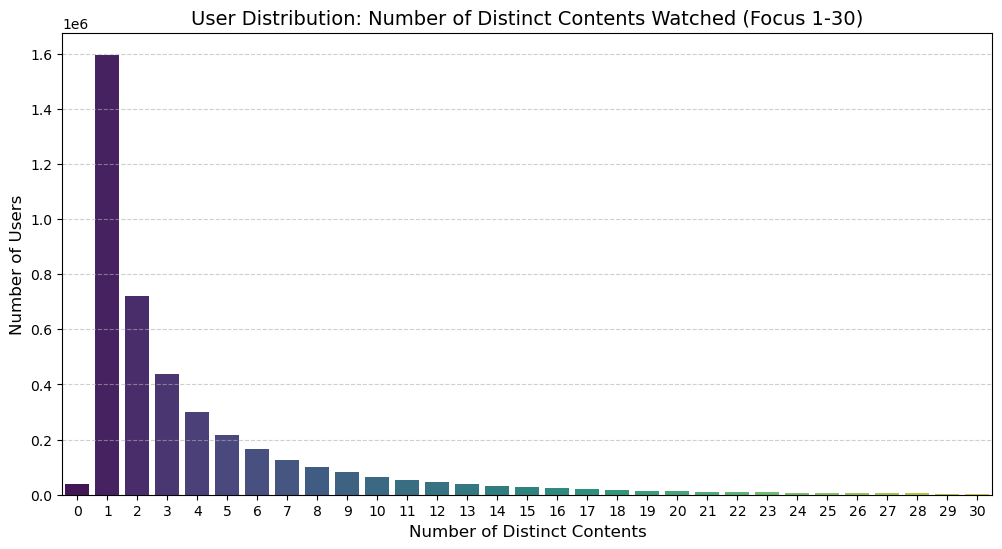

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate: Count how many users fall into each "content count" bucket
# We sort by the count of contents to make the X-axis linear (1, 2, 3...)
dist_data = (
    user_distinct_content_count_df
    .groupBy("distinct_content_count")
    .count()
    .orderBy("distinct_content_count")
)

# 2. Focus on "Lower Numbers": Filter for users with 1 to 30 contents 
# This prevents high-count outliers from squishing the graph
plot_df = dist_data.filter("distinct_content_count <= 30").toPandas()
# plot_df = dist_data.toPandas()

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    x="distinct_content_count", 
    y="count", 
    data=plot_df, 
    palette="viridis"
)

# Adding labels and styling
plt.title("User Distribution: Number of Distinct Contents Watched (Focus 1-30)", fontsize=14)
plt.xlabel("Number of Distinct Contents", fontsize=12)
plt.ylabel("Number of Users", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [83]:
print("Users watching  1 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 1").count())
print("Users watching  2 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 2").count())
print("Users watching  3 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 3").count())
print("Users watching  5 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 5").count())
print("Users watching  10 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 10").count())
print("Users watching  20 content:\t", user_distinct_content_count_df.filter("distinct_content_count == 20").count())
print("Users watching >= 50 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 50").count())
print("Users watching >= 100 content:\t", user_distinct_content_count_df.filter("distinct_content_count >= 100").count())

Users watching  1 content:	 1595669
Users watching  2 content:	 719439
Users watching  3 content:	 439256
Users watching  5 content:	 217899
Users watching  10 content:	 65889
Users watching  20 content:	 12659
Users watching >= 50 content:	 7732
Users watching >= 100 content:	 392


In [84]:
# Define the percentiles you want (expressed as decimals 0.0 to 1.0)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Calculate the values
# 0.01 is the relative error: lower is more accurate but slower
quantile_values = user_distinct_content_count_df.stat.approxQuantile(
    "distinct_content_count", 
    percentiles, 
    0.01
)

# Pair them up and print the results
print("--- User Content Consumption Percentiles ---")
for p, v in zip(percentiles, quantile_values):
    print(f"{int(p*100)}th Percentile: {int(v)} contents")

--- User Content Consumption Percentiles ---
25th Percentile: 1 contents
50th Percentile: 2 contents
75th Percentile: 5 contents
90th Percentile: 9 contents
95th Percentile: 13 contents
99th Percentile: 1581 contents


## ALS implementation

ALS only accepts integer values

#### test

In [85]:
# spark.conf.set("spark.kryoserializer.buffer", "64m")
# spark.conf.set("spark.kryoserializer.buffer.max", "512m")

In [86]:
# from pyspark.sql.functions import monotonically_increasing_id

# # Create user mapping table
# user_lookup = (
#     user_normalized
#     .select("userid")
#     .distinct()
#     .withColumn("userIndex", monotonically_increasing_id())
# )

# # Create item mapping table
# item_lookup = (
#     user_normalized
#     .select("content_id")
#     .distinct()
#     .withColumn("itemIndex", monotonically_increasing_id())
# )

# # Join mappings back to main dataset
# als_data = (
#     user_normalized
#     .join(user_lookup, "userid")
#     .join(item_lookup, "content_id")
# )

# # Keep only columns needed for ALS
# als_data = als_data.select("userIndex", "itemIndex", "playtime_log")

In [87]:
# from pyspark.ml.feature import StringIndexer


# user_indexer = StringIndexer(
#     inputCol="userid",
#     outputCol="userIndex",
#     handleInvalid="skip"
# )

# item_indexer = StringIndexer(
#     inputCol="content_id",
#     outputCol="itemIndex",   # 000000
#     handleInvalid="skip"
# )

# als_data = user_indexer.fit(user_normalized).transform(user_normalized)
# als_data = item_indexer.fit(als_data).transform(als_data)

# # Create lookup tables BEFORE dropping columns
# user_lookup = als_data.select("userid", "userIndex").distinct()
# item_lookup = als_data.select("content_id", "itemIndex").distinct()

# # Keep only columns needed for ALS to reduce memory footprint
# als_data = als_data.select("userIndex", "itemIndex", "playtime_log")

### als data prep

In [88]:
#test for row numbers
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

user_window = Window.orderBy("userid")

user_lookup = (
    labeled_data
    .select("userid")
    .distinct()
    .withColumn("userIndex", row_number().over(user_window))
)   
item_window = Window.orderBy("item_id")

item_lookup = (
    labeled_data
    .select("item_id")
    .distinct()
    .withColumn("itemIndex", row_number().over(item_window))
)

als_data = (
    labeled_data
    .join(user_lookup, "userid")
    .join(item_lookup, "item_id")
)   
als_data = als_data.select(
    "userIndex",
    "itemIndex",
    "rating_label_custom"
    ).repartition(5000)

In [89]:
# # Removing Null and NaN values for a quick fix
# als_data = als_data.filter(
#     F.col("playtime_log").isNotNull()
# ).filter(
#     ~F.isnan("playtime_log")
# )

Training ALS Model

In [90]:
from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="userIndex",
    itemCol="itemIndex",
    ratingCol="rating_label_custom", #using log because of skewness in playtime distribution
    implicitPrefs=True,
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop"
)

model = als.fit(als_data)

# Cache model predictions for reuse
recommendations = model.recommendForAllUsers(10)
recommendations.cache()

26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:14:51 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 1

DataFrame[userIndex: int, recommendations: array<struct<itemIndex:int,rating:float>>]

In [91]:
recommendations = model.recommendForAllUsers(10)

## Transforming Recommendations into suitable format

In [92]:
import pyspark.sql.functions as F

rec_exploded = recommendations.select(
    "userIndex",
    F.explode("recommendations").alias("rec")
)
rec_exploded = rec_exploded.select(
    "userIndex",
    F.col("rec.itemIndex"),
    F.col("rec.rating")
)

In [93]:
# Lookups already created in previous cell
final_recommendations = rec_exploded \
    .join(user_lookup, "userIndex") \
    .join(item_lookup, "itemIndex")

In [94]:
final_recommendations = final_recommendations.orderBy(
    "userid",
    F.desc("rating")
)

In [95]:
watched = labeled_data.select("userid", "item_id")

final_recommendations = final_recommendations.join(
    watched,
    ["userid", "item_id"],
    "left_anti"
)   

window = Window.partitionBy("userid").orderBy(F.desc("rating"))

final_recommendations = final_recommendations.withColumn(
    "rank",
    F.row_number().over(window)
).filter("rank <= 5").cache()  # Cache for reuse in comparison table

26/03/10 11:16:32 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 30 for reason Executor for container container_1764236692086_4795_01_000053 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/10 11:16:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:16:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:16:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:16:32 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [96]:
# final_recommendations.orderBy("userid", "rank").show(100, False)

### Organising to contrast between top viewed content and the recommended content

In [97]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

w_user = Window.partitionBy("userid").orderBy(F.desc("total_playtime_combined"))

top_watched = (
    labeled_data
    .withColumn("rank_watched", F.row_number().over(w_user))
    .filter(F.col("rank_watched") <= 5)
    .select(
        "userid",
        F.col("item_id").alias("watched_content_id"),
        "rank_watched"
    )
)


w_reco = Window.partitionBy("userid").orderBy(F.desc("rating"))

top_reco = (
    final_recommendations
    .withColumn("rank_reco", F.row_number().over(w_reco))
    .filter(F.col("rank_reco") <= 5)
    .select(
        "userid",
        F.col("item_id").alias("reco_content_id"),
        "rank_reco"
    )
)


comparison_table = (
    top_watched.alias("w")
    .join(
        top_reco.alias("r"),
        (F.col("w.userid") == F.col("r.userid")) &
        (F.col("w.rank_watched") == F.col("r.rank_reco")),
        "inner"
    )
    .select(
        F.col("w.userid").alias("userId"),
        "watched_content_id",
        "rank_watched",
        "reco_content_id",
        F.col("rank_reco")
    )
)

In [ ]:
comparison_table.orderBy("userId","rank_watched").show(100, False)

26/03/10 11:16:35 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 33 for reason Executor for container container_1764236692086_4795_01_000056 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/10 11:16:35 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 32 for reason Executor for container container_1764236692086_4795_01_000055 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/10 11:16:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:16:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/10 11:16:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partitio

+-------------------+---------------------------------------------------------------+------------+---------------------------------------------------------------+---------+
|userId             |watched_content_id                                             |rank_watched|reco_content_id                                                |rank_reco|
+-------------------+---------------------------------------------------------------+------------+---------------------------------------------------------------+---------+
|                   |SONYLIV_VOD_TVSHOW_1700000741                                  |1           |AHA_MOVIE_F262E7FE-EE7A-4743-B06A-A5E3C71CDD67                 |1        |
|'-uxFhnas78V-64lxk0|SONYLIV_VOD_TVSHOW_1700000221                                  |1           |SONYLIV_VOD_TVSHOW_1700001014                                  |1        |
|'-uxFhnas78V-64lxk0|SONYLIV_VOD_TVSHOW_1700001090                                  |2           |SONYLIV_VOD_TVSHOW_1700000741        

26/03/10 11:20:16 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 46 for reason Executor for container container_1764236692086_4795_01_000074 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/03/10 11:20:16 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 13 for reason Executor for container container_1764236692086_4795_01_000026 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
